------------------
```markdown
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amendments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com
```
------------------------------
❗❗❗ **IMPORTANT**❗❗❗ **Create a copy of this notebook**

In order to work with this Google Colab you need to create a copy of it. Please **DO NOT** provide your answers here. Instead, work on the copy version. To make a copy:

**Click on: File -> save a copy in drive**

Have you successfully created the copy? if yes, there must be a new tab opened in your browser. Now move to the copy and start from there!

----------------------------------------------

# Bayesian Calibration of Agent-Based Models

## Learning Objectives

By the end of this notebook, you will be able to:
1. Understand why ABM calibration requires likelihood-free methods
2. Implement Approximate Bayesian Computation (ABC) using PyMC
3. Apply Sequential Monte Carlo ABC (ABC-SMC) for efficient calibration
4. Calibrate the Schelling segregation model to match observed data
5. Validate calibration results using posterior predictive checks

## Introduction: The Calibration Challenge

ABMs have many parameters that must be set to regenerate real-world patterns. The central question is: **how?**

Suppose we observe segregation in a city: $y^* = 0.78$. We want our Schelling model (with unknown tolerance $\theta$) to produce the same segregation.

**Mathematically:** We want the posterior $p(\theta | y^*)$

By Bayes' theorem:
$$p(\theta | y^*) = \frac{p(y^* | \theta) p(\theta)}{p(y^*)}$$

**BUT** we cannot write down $p(y | \theta)$ analytically because:
- ABMs are **simulators**, not probability distributions
- We can generate data: $y_{\text{sim}} \sim \text{ABM}(\theta)$
- We **cannot** evaluate: $p(y | \theta) = \ ???$

This notebook shows how to do Bayesian inference **without** explicit likelihoods using PyMC.

## Setup and Imports

In [1]:
# Install required packages (run once)
!pip install -q pymc arviz scikit-learn

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import random

# Bayesian inference
import pymc as pm
import arviz as az

# For emulator (optional advanced section)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# Set random seeds
np.random.seed(42)
random.seed(42)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Schelling Model Setup

We'll use a simplified Schelling model. The key is that we can **run** it but cannot write its likelihood.

In [2]:
# Model constants
GRID_SIZE = 50
EMPTY_CELL = 0
AGENT_TYPE_A = 1
AGENT_TYPE_B = 2

class Agent:
    def __init__(self, x, y, agent_type, similarity_threshold):
        self.x = x
        self.y = y
        self.agent_type = agent_type
        self.similarity_threshold = similarity_threshold

    def is_happy(self, environment):
        """Check if agent is happy with current neighborhood."""
        similar, total = 0, 0
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                nx = (self.x + dx) % GRID_SIZE
                ny = (self.y + dy) % GRID_SIZE
                neighbor_type = environment.grid[nx, ny]
                if neighbor_type != EMPTY_CELL:
                    total += 1
                    if neighbor_type == self.agent_type:
                        similar += 1
        if total == 0:
            return True
        similarity = similar / total
        return similarity >= self.similarity_threshold

class Environment:
    def __init__(self):
        self.grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

    def get_empty_cells(self):
        return [(x, y) for x in range(GRID_SIZE) for y in range(GRID_SIZE)
                if self.grid[x, y] == EMPTY_CELL]

    def place_agent(self, agent, x, y):
        self.grid[x, y] = agent.agent_type
        agent.x, agent.y = x, y

    def move_agent(self, agent, new_x, new_y):
        self.grid[agent.x, agent.y] = EMPTY_CELL
        self.grid[new_x, new_y] = agent.agent_type
        agent.x, agent.y = new_x, new_y

def calculate_segregation_index(grid):
    """Calculate average neighbor similarity (segregation metric)."""
    similarities = []
    for x in range(GRID_SIZE):
        for y in range(GRID_SIZE):
            if grid[x, y] == EMPTY_CELL:
                continue
            agent_type = grid[x, y]
            similar, total = 0, 0
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    if dx == 0 and dy == 0:
                        continue
                    nx, ny = (x + dx) % GRID_SIZE, (y + dy) % GRID_SIZE
                    if grid[nx, ny] != EMPTY_CELL:
                        total += 1
                        if grid[nx, ny] == agent_type:
                            similar += 1
            if total > 0:
                similarities.append(similar / total)
    return np.mean(similarities) if similarities else 0

class SchellingModel:
    def __init__(self, n_agents=2000, occupancy=0.8, similarity_threshold=0.3):
        self.n_agents = min(n_agents, int(GRID_SIZE * GRID_SIZE * occupancy))
        self.similarity_threshold = similarity_threshold
        self.env = Environment()
        self.agents = []
        self._initialize_agents()

    def _initialize_agents(self):
        positions = [(x, y) for x in range(GRID_SIZE) for y in range(GRID_SIZE)]
        random.shuffle(positions)
        for i in range(self.n_agents):
            x, y = positions[i]
            agent_type = AGENT_TYPE_A if i < self.n_agents // 2 else AGENT_TYPE_B
            agent = Agent(x, y, agent_type, self.similarity_threshold)
            self.env.place_agent(agent, x, y)
            self.agents.append(agent)

    def step(self):
        random.shuffle(self.agents)
        moves = 0
        for agent in self.agents:
            if not agent.is_happy(self.env):
                empty = self.env.get_empty_cells()
                if empty:
                    new_x, new_y = random.choice(empty)
                    self.env.move_agent(agent, new_x, new_y)
                    moves += 1
        return moves

    def run(self, max_steps=50):
        for step in range(max_steps):
            moves = self.step()
            if moves == 0:
                return step
        return max_steps

    def get_final_segregation(self):
        """Run model and return final segregation index."""
        self.run(max_steps=50)
        return calculate_segregation_index(self.env.grid)

print("Schelling model ready!")

Schelling model ready!


### Quick Test: Run the Model

Let's verify the model works and see how segregation varies with tolerance.

Tolerance = 0.2: Segregation = 0.574
Tolerance = 0.3: Segregation = 0.740
Tolerance = 0.4: Segregation = 0.799
Tolerance = 0.5: Segregation = 0.872


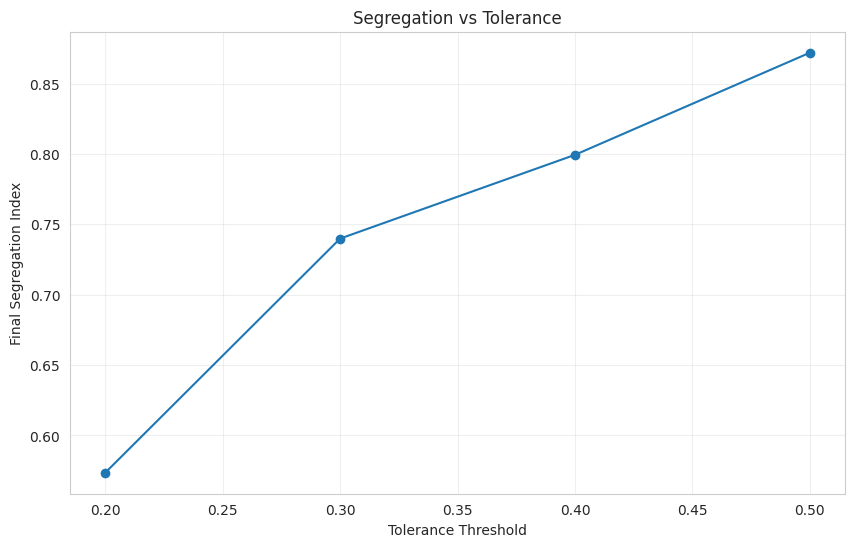

In [3]:
# Test different tolerance values
test_thresholds = [0.2, 0.3, 0.4, 0.5]
results = []

for threshold in test_thresholds:
    model = SchellingModel(similarity_threshold=threshold)
    seg = model.get_final_segregation()
    results.append(seg)
    print(f"Tolerance = {threshold:.1f}: Segregation = {seg:.3f}")

plt.plot(test_thresholds, results, 'o-')
plt.xlabel('Tolerance Threshold')
plt.ylabel('Final Segregation Index')
plt.title('Segregation vs Tolerance')
plt.grid(True, alpha=0.3)
plt.show()

## ABC Rejection Sampling (Manual Implementation)

Before using PyMC, let's implement ABC from scratch to understand the logic.

### The ABC Algorithm

1. Sample $\theta$ from prior
2. Simulate: $y_{\text{sim}} \sim \text{ABM}(\theta)$
3. Calculate distance: $d = |y_{\text{sim}} - y^*|$
4. Accept $\theta$ if $d < \epsilon$ (tolerance)
5. Repeat until N accepted samples

**Result:** Accepted samples $\approx p(\theta | y^*)$

In [4]:
def abc_rejection_manual(observed_segregation, n_samples=50, epsilon=0.04,
                         prior_low=0.2, prior_high=0.85, max_trials=500):
    """
    Manual ABC rejection sampling.

    Args:
        observed_segregation: Target segregation index (e.g., 0.78)
        n_samples: Number of accepted samples desired
        epsilon: Tolerance (acceptance threshold)
        prior_low, prior_high: Uniform prior bounds
        max_trials: Maximum simulation runs

    Returns:
        accepted_thetas: Array of accepted tolerance values
        acceptance_rate: Fraction of proposals accepted
    """
    accepted_thetas = []
    total_proposals = 0

    pbar = tqdm(total=n_samples, desc="ABC Rejection")

    while len(accepted_thetas) < n_samples and total_proposals < max_trials:
        # 1. Sample from prior
        theta = np.random.uniform(prior_low, prior_high)

        # 2. Simulate ABM
        model = SchellingModel(n_agents=2000, occupancy=0.8,
                               similarity_threshold=theta)
        simulated_segregation = model.get_final_segregation()

        # 3. Calculate distance
        distance = abs(simulated_segregation - observed_segregation)

        # 4. Accept/reject
        if distance < epsilon:
            accepted_thetas.append(theta)
            pbar.update(1)

        total_proposals += 1

    pbar.close()
    acceptance_rate = len(accepted_thetas) / total_proposals

    print(f"\nTotal proposals: {total_proposals}")
    print(f"Accepted samples: {len(accepted_thetas)}")
    print(f"Acceptance rate: {acceptance_rate:.2%}")

    return np.array(accepted_thetas), acceptance_rate

In [5]:
# Run ABC
print("Running ABC calibration...")
print("Observed segregation: 0.78")
print("This may take 3-5 minutes...\n")

observed_seg = 0.78
posterior_samples, acc_rate = abc_rejection_manual(
    observed_segregation=observed_seg,
    n_samples=25,
    epsilon=0.04
)

Running ABC calibration...
Observed segregation: 0.78
This may take 3-5 minutes...



ABC Rejection:   0%|          | 0/25 [00:00<?, ?it/s]


Total proposals: 174
Accepted samples: 25
Acceptance rate: 14.37%


### Visualize ABC Results

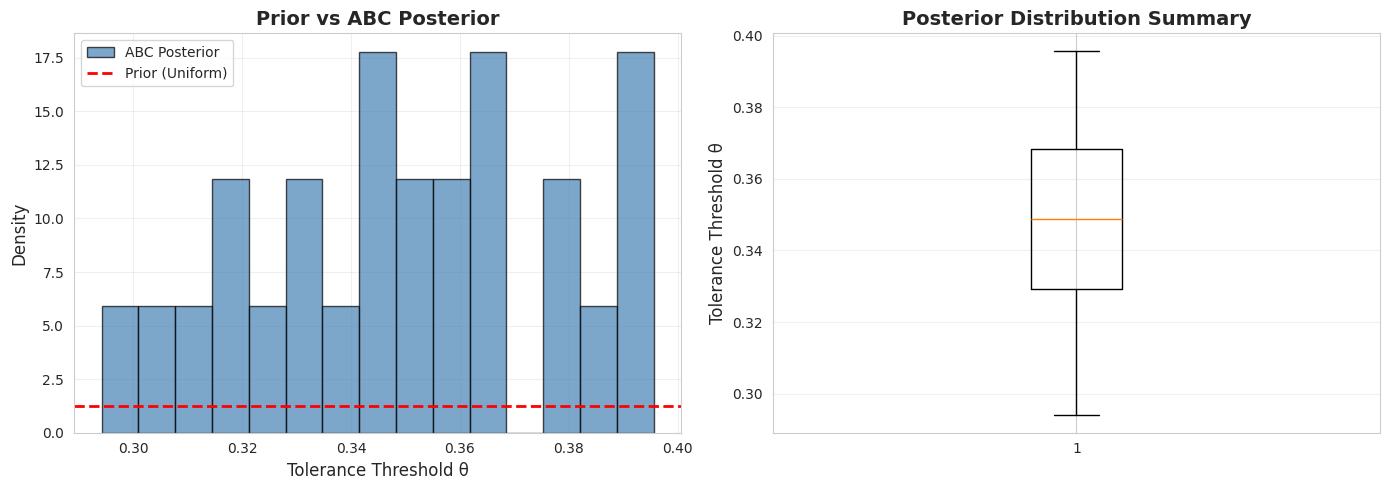


Posterior Summary:
Mean: 0.349
Median: 0.349
95% Credible Interval: [0.301, 0.392]


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prior vs Posterior
axes[0].hist(posterior_samples, bins=15, density=True, alpha=0.7,
             color='steelblue', edgecolor='black', label='ABC Posterior')
axes[0].axhline(y=1/(0.9-0.1), color='red', linestyle='--',
                linewidth=2, label='Prior (Uniform)')
axes[0].set_xlabel('Tolerance Threshold θ', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Prior vs ABC Posterior', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Posterior summary
axes[1].boxplot(posterior_samples, vert=True)
axes[1].set_ylabel('Tolerance Threshold θ', fontsize=12)
axes[1].set_title('Posterior Distribution Summary', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nPosterior Summary:")
print(f"Mean: {posterior_samples.mean():.3f}")
print(f"Median: {np.median(posterior_samples):.3f}")
print(f"95% Credible Interval: [{np.percentile(posterior_samples, 2.5):.3f}, "
      f"{np.percentile(posterior_samples, 97.5):.3f}]")

## Sequential Monte Carlo ABC (ABC-SMC)

ABC rejection is wasteful—many simulations get rejected. **ABC-SMC** solves this by:
1. Starting with loose tolerance $\epsilon_1$ (easy to accept)
2. Gradually tightening tolerance: $\epsilon_2 < \epsilon_1$
3. Using previous particles as proposals (adaptive)
4. Much more efficient!


In [7]:
def abc_smc(observed_value, n_particles=500, n_iterations=5,
           prior_low=0.1, prior_high=0.9, initial_epsilon=0.15):
    """
    ABC Sequential Monte Carlo implementation.

    Args:
        observed_value: Target segregation index
        n_particles: Number of particles per iteration
        n_iterations: Number of SMC iterations
        prior_low, prior_high: Prior bounds
        initial_epsilon: Starting tolerance

    Returns:
        particles: Final particle positions (posterior samples)
        weights: Final particle weights
        history: Dictionary with iteration history
    """
    # Storage for history
    history = {
        'epsilons': [],
        'acceptance_rates': [],
        'particles_per_iter': []
    }

    # Initialize: Sample from prior
    print("Iteration 0: Sampling from prior...")
    particles = np.random.uniform(prior_low, prior_high, n_particles)
    weights = np.ones(n_particles) / n_particles  # Uniform weights

    # Calculate tolerance schedule (geometric decay)
    final_epsilon = 0.03  # Target final tolerance
    epsilons = np.geomspace(initial_epsilon, final_epsilon, n_iterations)

    # ABC-SMC iterations
    for iteration in range(n_iterations):
        epsilon = epsilons[iteration]
        print(f"\nIteration {iteration+1}/{n_iterations}: epsilon = {epsilon:.4f}")

        new_particles = []
        new_weights = []
        proposals = 0

        # Sample new particles
        pbar = tqdm(total=n_particles, desc=f"  Sampling")

        while len(new_particles) < n_particles:
            # Sample particle from previous population (weighted)
            idx = np.random.choice(len(particles), p=weights)
            theta_old = particles[idx]

            # Perturb with kernel (Gaussian random walk)
            perturbation_scale = 0.05 * (prior_high - prior_low)  # 5% of range
            theta_new = theta_old + np.random.normal(0, perturbation_scale)

            # Enforce prior bounds
            if theta_new < prior_low or theta_new > prior_high:
                continue

            # Simulate ABM
            model = SchellingModel(
                n_agents=2000,
                occupancy=0.8,
                similarity_threshold=theta_new
            )
            simulated_value = model.get_final_segregation()

            # Calculate distance
            distance = abs(simulated_value - observed_value)
            proposals += 1

            # Accept if within tolerance
            if distance < epsilon:
                new_particles.append(theta_new)

                # Calculate importance weight
                # prior(theta) / proposal(theta | previous)
                prior_prob = 1.0 / (prior_high - prior_low)  # Uniform prior

                # Proposal is mixture of previous particles with perturbation
                proposal_prob = np.mean([
                    weights[k] * scipy.stats.norm.pdf(theta_new, particles[k], perturbation_scale)
                    for k in range(len(particles))
                ])

                weight = prior_prob / (proposal_prob + 1e-10)  # Avoid division by zero
                new_weights.append(weight)

                pbar.update(1)

        pbar.close()

        # Normalize weights
        new_weights = np.array(new_weights)
        new_weights = new_weights / new_weights.sum()

        # Update particles and weights
        particles = np.array(new_particles)
        weights = new_weights

        # Store history
        acceptance_rate = n_particles / proposals
        history['epsilons'].append(epsilon)
        history['acceptance_rates'].append(acceptance_rate)
        history['particles_per_iter'].append(particles.copy())

        print(f"  Acceptance rate: {acceptance_rate:.2%}")
        print(f"  Mean theta: {np.average(particles, weights=weights):.3f}")

    return particles, weights, history

print("ABC-SMC function defined!")

ABC-SMC function defined!


### Sample with SMC

**Note:** This will take several minutes. SMC runs multiple iterations, adaptively improving the posterior.

In [8]:
# Run ABC-SMC
print("Running ABC-SMC...")
print("This will take 5-10 minutes...\n")

import scipy.stats  # Needed for importance weights

particles_smc, weights_smc, history_smc = abc_smc(
    observed_value=observed_seg,
    n_particles=25,      # Particles per iteration
    n_iterations=3,       # Number of SMC iterations
    initial_epsilon=0.15  # Starting tolerance
)

print("\n" + "="*60)
print("ABC-SMC Complete!")
print("="*60)
print(f"Final particles: {len(particles_smc)}")
print(f"Weighted mean: {np.average(particles_smc, weights=weights_smc):.3f}")
print(f"Weighted std: {np.sqrt(np.average((particles_smc - np.average(particles_smc, weights=weights_smc))**2, weights=weights_smc)):.3f}")

Running ABC-SMC...
This will take 5-10 minutes...

Iteration 0: Sampling from prior...

Iteration 1/3: epsilon = 0.1500


  Sampling:   0%|          | 0/25 [00:00<?, ?it/s]

  Acceptance rate: 25.51%
  Mean theta: 0.372

Iteration 2/3: epsilon = 0.0671


  Sampling:   0%|          | 0/25 [00:00<?, ?it/s]

  Acceptance rate: 71.43%
  Mean theta: 0.365

Iteration 3/3: epsilon = 0.0300


  Sampling:   0%|          | 0/25 [00:00<?, ?it/s]

  Acceptance rate: 42.37%
  Mean theta: 0.365

ABC-SMC Complete!
Final particles: 25
Weighted mean: 0.365
Weighted std: 0.019


### Analyze SMC Results with ArviZ

In [ ]:
# Visualize SMC progression
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Tolerance schedule
axes[0, 0].plot(range(1, len(history_smc['epsilons'])+1),
                history_smc['epsilons'], 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('SMC Iteration', fontsize=12)
axes[0, 0].set_ylabel('Tolerance (ε)', fontsize=12)
axes[0, 0].set_title('Adaptive Tolerance Schedule', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Acceptance rates
axes[0, 1].plot(range(1, len(history_smc['acceptance_rates'])+1),
                [r*100 for r in history_smc['acceptance_rates']], 'o-',
                linewidth=2, markersize=8, color='coral')
axes[0, 1].set_xlabel('SMC Iteration', fontsize=12)
axes[0, 1].set_ylabel('Acceptance Rate (%)', fontsize=12)
axes[0, 1].set_title('Acceptance Rate per Iteration', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Particle evolution (violin plots)
positions = []
for iter_idx, particles in enumerate(history_smc['particles_per_iter']):
    positions.append(particles)

parts = axes[1, 0].violinplot(positions, positions=range(1, len(positions)+1),
                               showmeans=True, showmedians=True)
axes[1, 0].set_xlabel('SMC Iteration', fontsize=12)
axes[1, 0].set_ylabel('Tolerance Threshold (θ)', fontsize=12)
axes[1, 0].set_title('Particle Distribution Evolution', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Final weighted histogram
axes[1, 1].hist(particles_smc, bins=20, weights=weights_smc, density=True,
                alpha=0.7, edgecolor='black', color='purple', label='ABC-SMC (weighted)')
axes[1, 1].axvline(np.average(particles_smc, weights=weights_smc),
                   color='red', linestyle='--', linewidth=2.5, label='Weighted Mean')
axes[1, 1].set_xlabel('Tolerance Threshold (θ)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Final Weighted Posterior', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("1. Tolerance decreases geometrically (top-left)")
print("2. Acceptance rate decreases as tolerance tightens (top-right)")
print("3. Particle distribution narrows over iterations (bottom-left)")
print("4. Final posterior is concentrated around true value (bottom-right)")

### Compare ABC Rejection vs ABC-SMC

In [ ]:
import pandas as pd

# Compare both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior comparison
axes[0].hist(posterior_samples, bins=20, density=True, alpha=0.6,
             color='steelblue', label='ABC Rejection', edgecolor='black')
axes[0].hist(particles_smc, bins=20, weights=weights_smc, density=True, alpha=0.6,
             color='coral', label='ABC-SMC (weighted)', edgecolor='black')
axes[0].axhline(y=1/(0.9-0.1), color='gray', linestyle='--', linewidth=2,
                label='Prior (Uniform)', alpha=0.7)
axes[0].set_xlabel('Tolerance Threshold θ', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Comparison: ABC Rejection vs ABC-SMC', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Summary statistics
rejection_mean = posterior_samples.mean()
rejection_std = posterior_samples.std()
smc_mean = np.average(particles_smc, weights=weights_smc)
smc_std = np.sqrt(np.average((particles_smc - smc_mean)**2, weights=weights_smc))

summary_data = {
    'Method': ['ABC Rejection', 'ABC-SMC'],
    'Mean': [rejection_mean.round(4), smc_mean.round(4)],
    'Std': [rejection_std.round(4), smc_std.round(4)],
    'Samples': [len(posterior_samples), len(particles_smc)]
}
summary_df = pd.DataFrame(summary_data)

# Display table
axes[1].axis('off')
table = axes[1].table(cellText=summary_df.values,
                      colLabels=summary_df.columns,
                      cellLoc='center', loc='center',
                      colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style table
for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

axes[1].set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nComparison Summary:")
print("="*60)
print(f"ABC Rejection:  Mean = {rejection_mean:.3f}, SD = {rejection_std:.3f}")
print(f"ABC-SMC:        Mean = {smc_mean:.3f}, SD = {smc_std:.3f}")
print("="*60)
print("\n✓ Both methods give similar results")
print("✓ ABC-SMC is more efficient (adaptive tolerance)")
print("✓ ABC-SMC provides importance weights for better inference")

## Part 3: Posterior Predictive Checks (Validation)

**Question:** Do our calibrated parameters actually reproduce the observed data?

We'll sample tolerance values from the posterior and run the model to see the distribution of segregation it produces.

In [15]:
# Sample parameters from posterior
n_pp_samples = 200
theta_samples = np.random.choice(particles_smc, size=n_pp_samples, replace=True)

# Run model for each sampled theta
pp_segregation = []

print("Running posterior predictive checks...")
for theta in tqdm(theta_samples, desc="Posterior Predictive"):
    model = SchellingModel(similarity_threshold=theta)
    seg = model.get_final_segregation()
    pp_segregation.append(seg)

pp_segregation = np.array(pp_segregation)

Running posterior predictive checks...


Posterior Predictive:   0%|          | 0/200 [00:00<?, ?it/s]

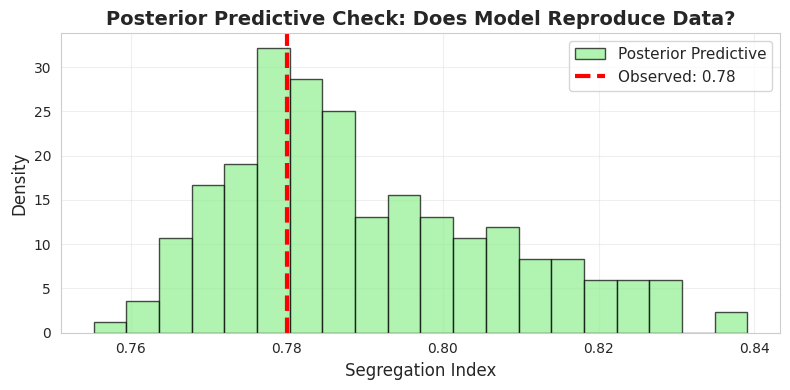


Posterior Predictive p-value: 0.675
Interpretation: 67.5% of simulations produce segregation ≥ observed
95% Posterior Predictive Interval: [0.765, 0.827]
✓ Observed data is within 95% PP interval - Good fit!


In [16]:
# Plot posterior predictive distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(pp_segregation, bins=20, density=True, alpha=0.7,
        color='lightgreen', edgecolor='black', label='Posterior Predictive')
ax.axvline(observed_seg, color='red', linestyle='--', linewidth=3,
           label=f'Observed: {observed_seg}')

ax.set_xlabel('Segregation Index', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Posterior Predictive Check: Does Model Reproduce Data?',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate p-value: how extreme is observed data?
p_value = np.mean(pp_segregation >= observed_seg)
print(f"\nPosterior Predictive p-value: {p_value:.3f}")
print(f"Interpretation: {p_value*100:.1f}% of simulations produce segregation ≥ observed")

# Check if observed is within 95% interval
lower, upper = np.percentile(pp_segregation, [2.5, 97.5])
print(f"95% Posterior Predictive Interval: [{lower:.3f}, {upper:.3f}]")
if lower <= observed_seg <= upper:
    print("✓ Observed data is within 95% PP interval - Good fit!")
else:
    print("✗ Observed data is outside 95% PP interval - Model may be mis-specified")

## Exercise 1: Effect of Tolerance (Epsilon)

Try running ABC with different tolerance values:
- `epsilon = 0.02` (tighter)
- `epsilon = 0.06` (looser)

**Questions:**
1. How does acceptance rate change?
2. How does posterior width change?
3. Which epsilon gives better results?

In [ ]:
# YOUR CODE HERE
# Hint: Run abc_rejection_manual() with different epsilon values


## Exercise 2: Multiple Summary Statistics

Instead of just matching final segregation, calibrate to match **two** patterns:
1. Final segregation index
2. Number of steps to convergence

Modify the simulator function to return both statistics.

**Hint:** Use Euclidean distance: $d = \sqrt{(s_1 - s_1^*)^2 + (s_2 - s_2^*)^2}$

In [14]:
# YOUR CODE HERE
# Modify SchellingModel to track convergence steps
# Implement multi-statistic ABC
